In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import gsw
import numpy as np
from mpl_toolkits.basemap import Basemap

In [15]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980]
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

(array([ 652909.,  689925.,  796135.,  819751., 1034316.,  907999.,
         998985., 1298356., 1430687., 1115588.,  912280.,  745986.]),
 array([ 1.        ,  1.91666667,  2.83333333,  3.75      ,  4.66666667,
         5.58333333,  6.5       ,  7.41666667,  8.33333333,  9.25      ,
        10.16666667, 11.08333333, 12.        ]),
 <BarContainer object of 12 artists>)

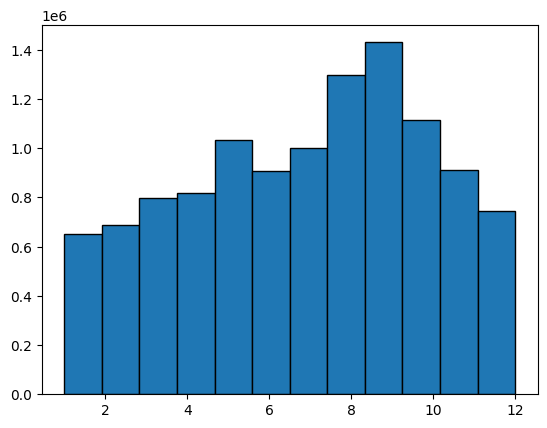

In [16]:
plt.hist(df_ST['month'], bins=12, edgecolor='black')

In [17]:
def sample_month_bins(df):
    # Create a new column for month bins
    df['month_bin'] = pd.cut(df['month'], bins=12, labels=False)

    # Find bin with least points and how many points it has to use as cutoff
    min_bin_count = df['month_bin'].value_counts().min()
    min_bin = df['month_bin'].value_counts().idxmin()
    print(f"Minimum bin count: {min_bin_count} in month bin: {min_bin}")

    # Sample from each bin to have the same number of points as the minimum bin
    sampled_df = df.groupby('month_bin').apply(lambda x: x.sample(min_bin_count)).reset_index(drop=True)

    return sampled_df

In [18]:
df_sampled = sample_month_bins(df_ST)

Minimum bin count: 652909 in month bin: 0


/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_77948/2732918037.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('month_bin').apply(lambda x: x.sample(min_bin_count)).reset_index(drop=True)


(array([652909., 652909., 652909., 652909., 652909., 652909., 652909.,
        652909., 652909., 652909., 652909., 652909.]),
 array([ 1.        ,  1.91666667,  2.83333333,  3.75      ,  4.66666667,
         5.58333333,  6.5       ,  7.41666667,  8.33333333,  9.25      ,
        10.16666667, 11.08333333, 12.        ]),
 <BarContainer object of 12 artists>)

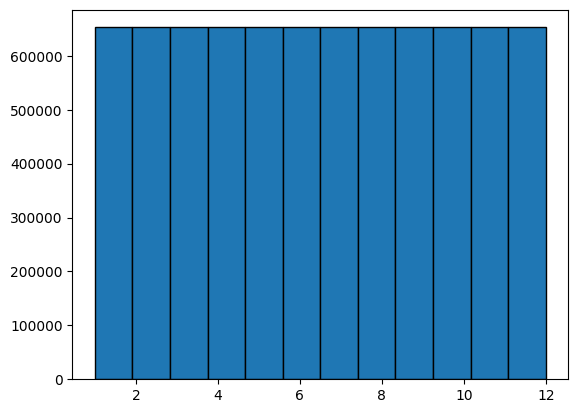

In [19]:
plt.hist(df_sampled['month'], bins=12, edgecolor='black')

In [20]:
def plot_heatmap_xy(ds_cleaned, n_x_bins=100, n_y_bins=100, bin_max=None, projection='npstere', projection_name='Polar Stereographic'):
    lat_min = ds_cleaned['Latitude_[deg_N]'].min()
    resolution = 'l'

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution=resolution)

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values
    depth_vals = ds_cleaned['Depth_[m]'].values

    # Reproject lat/lon to x/y
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Grid to store max depth
    H = np.zeros((n_x_bins, n_y_bins))

    # Digitize into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Fill grid with max depth
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            if depth_vals[i] > H[xi, yi]:
                H[xi, yi] = depth_vals[i]

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_bins, y_bins)

    # Colormap
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    # Plot heatmap
    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Optional: draw bin grid (in xy space)
    for xb in x_bins:
        plt.plot([xb]*len(y_bins), y_bins, color='grey', linewidth=0.05, zorder=3)
    for yb in y_bins:
        plt.plot(x_bins, [yb]*len(x_bins), color='grey', linewidth=0.05, zorder=3)

    # Plot coastlines on top
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Max Depth [m]')

    plt.xticks([])
    plt.yticks([])
    plt.title('Max Depth per Bin '+ f'({projection_name} Projection)')

    plt.show()
    print(f'bin max={bin_max}')

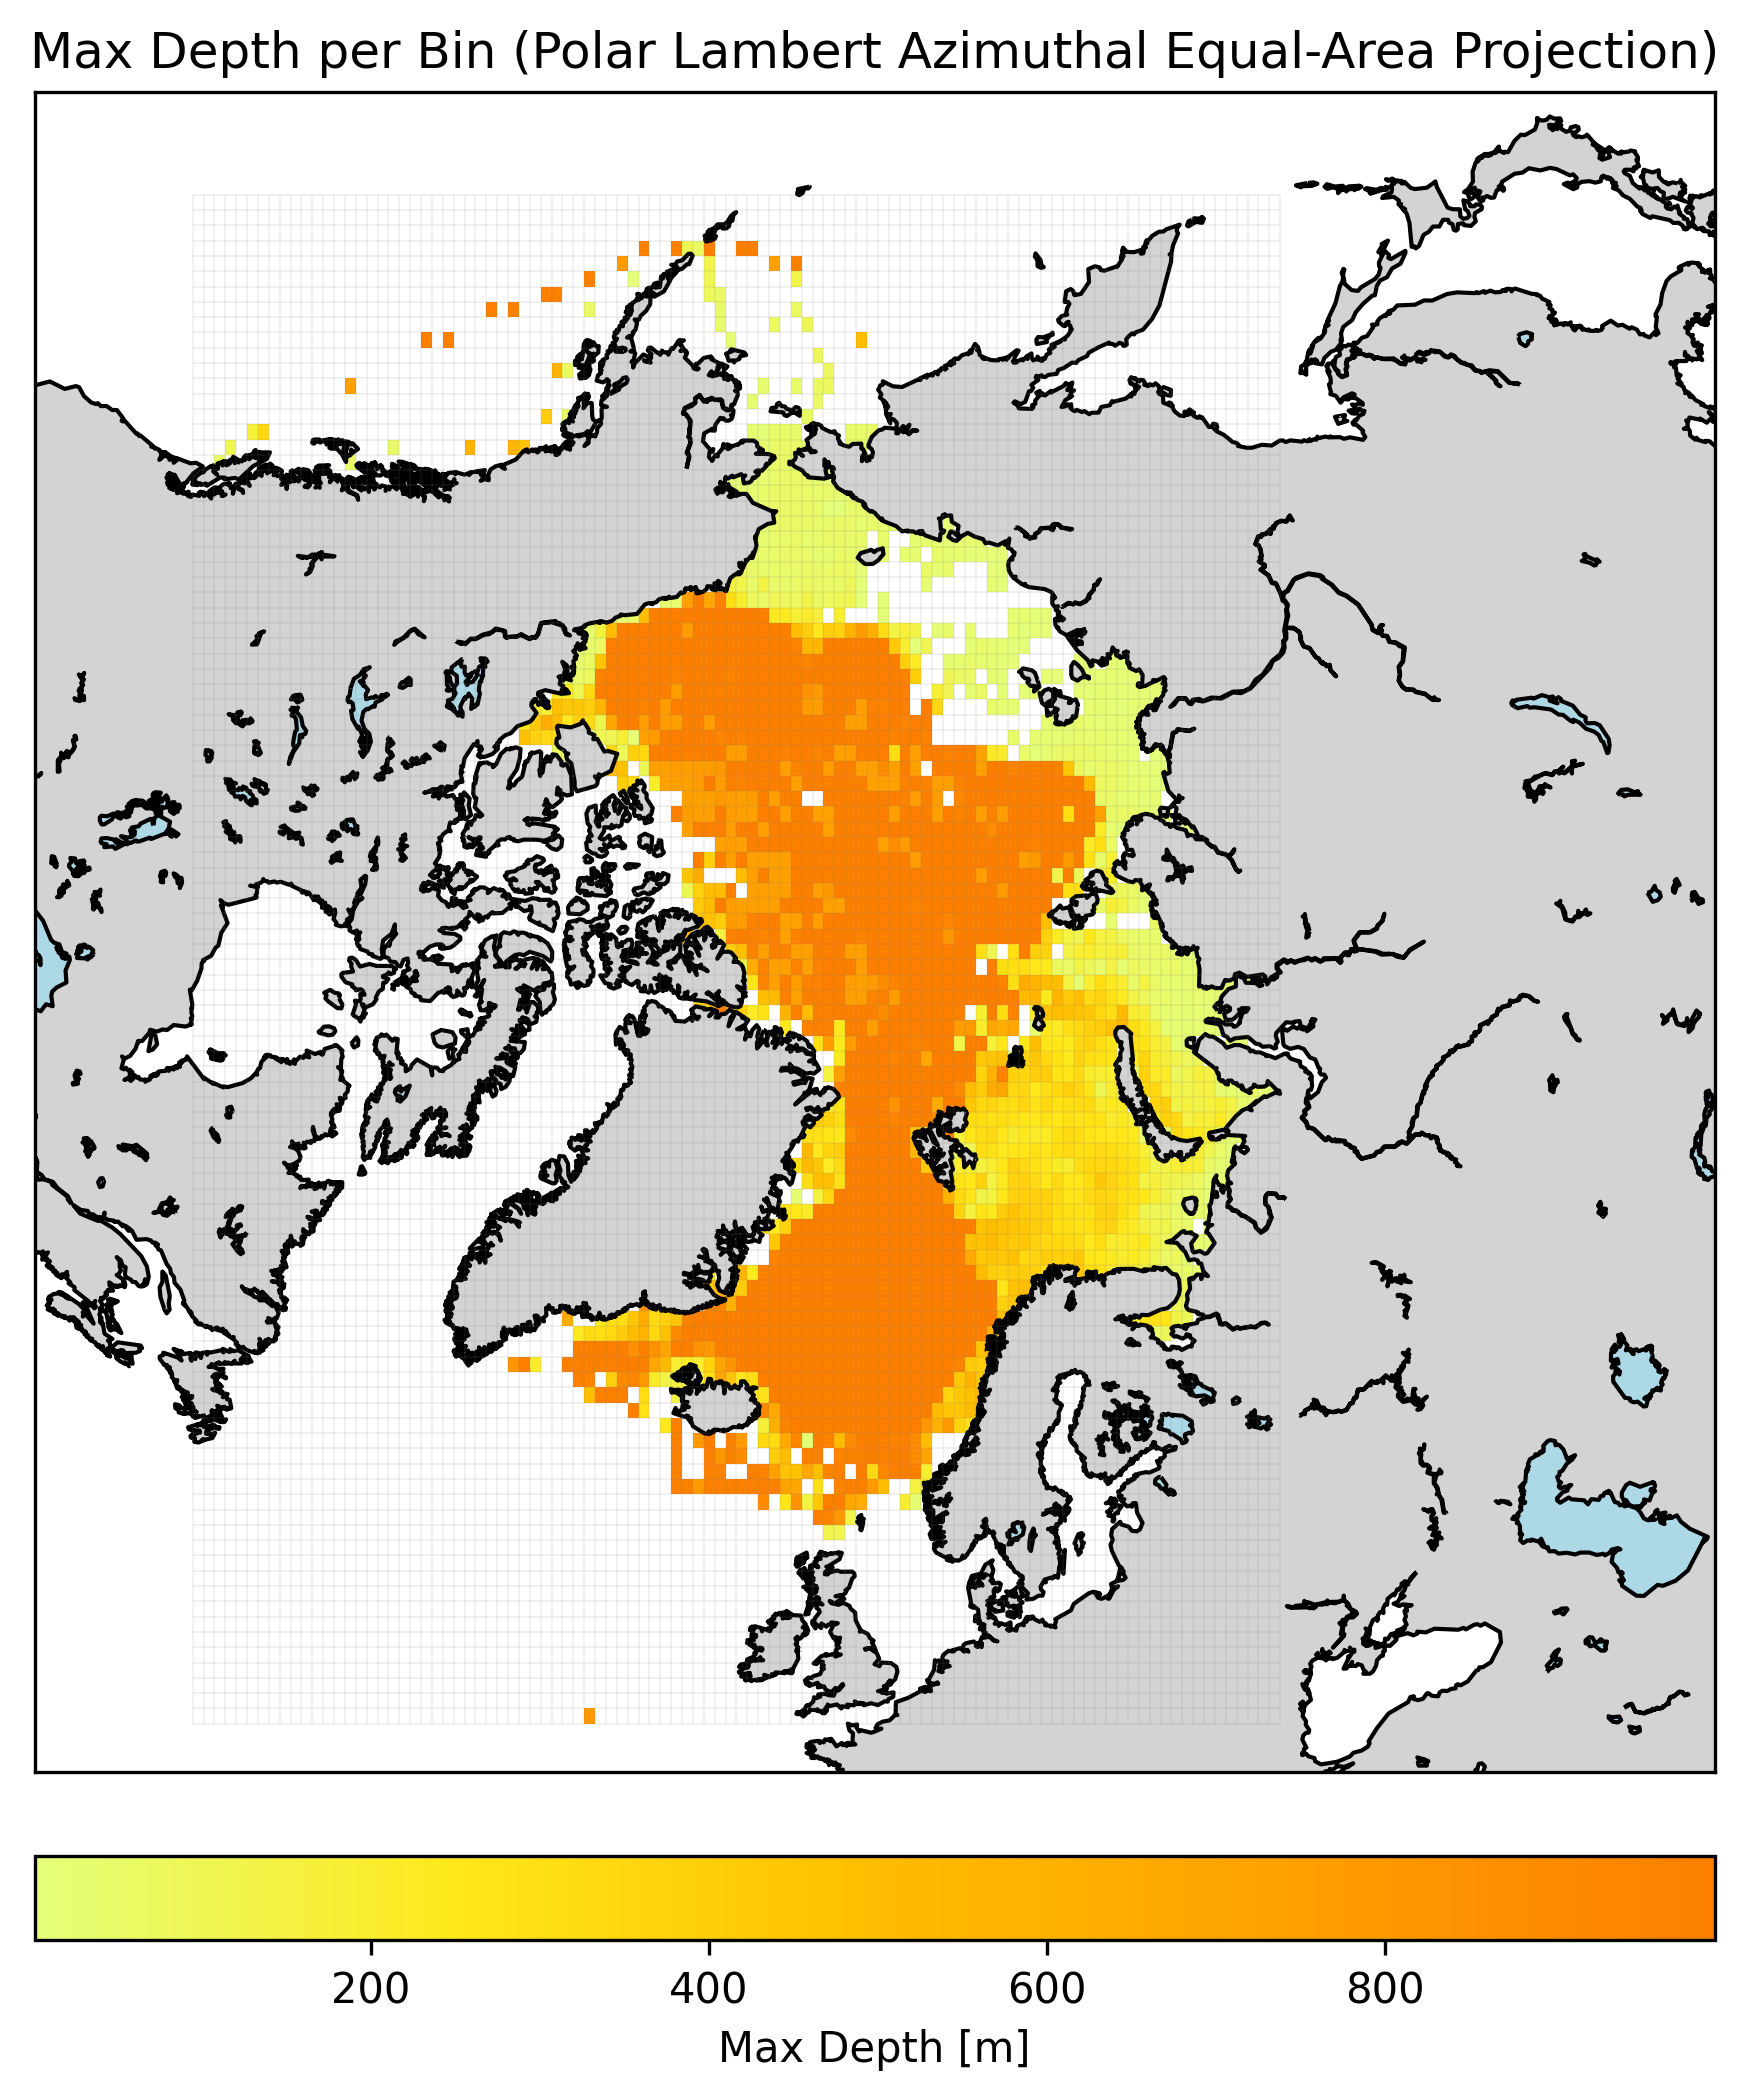

bin max=995.0


In [21]:
plot_heatmap_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='nplaea', projection_name='Polar Lambert Azimuthal Equal-Area')

In [22]:
def plot_heatmap_npts_xy(ds_cleaned, n_x_bins=100, n_y_bins=100, bin_max=None, projection='npstere', projection_name='Polar Stereographic'):
    lat_min = ds_cleaned['Latitude_[deg_N]'].min()
    resolution = 'l'

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution=resolution)

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    # Reproject lat/lon to x/y
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Grid to store max depth
    H = np.zeros((n_x_bins, n_y_bins))

    # Digitize into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of points in each bin
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_bins, y_bins)

    # Colormap
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    # Plot heatmap
    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Draw bin grid (in xy space)
    for xb in x_bins:
        plt.plot([xb]*len(y_bins), y_bins, color='grey', linewidth=0.05, zorder=3)
    for yb in y_bins:
        plt.plot(x_bins, [yb]*len(x_bins), color='grey', linewidth=0.05, zorder=3)

    # Plot coastlines on top
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points per bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin '+ f'({projection_name} Projection)')

    plt.show()

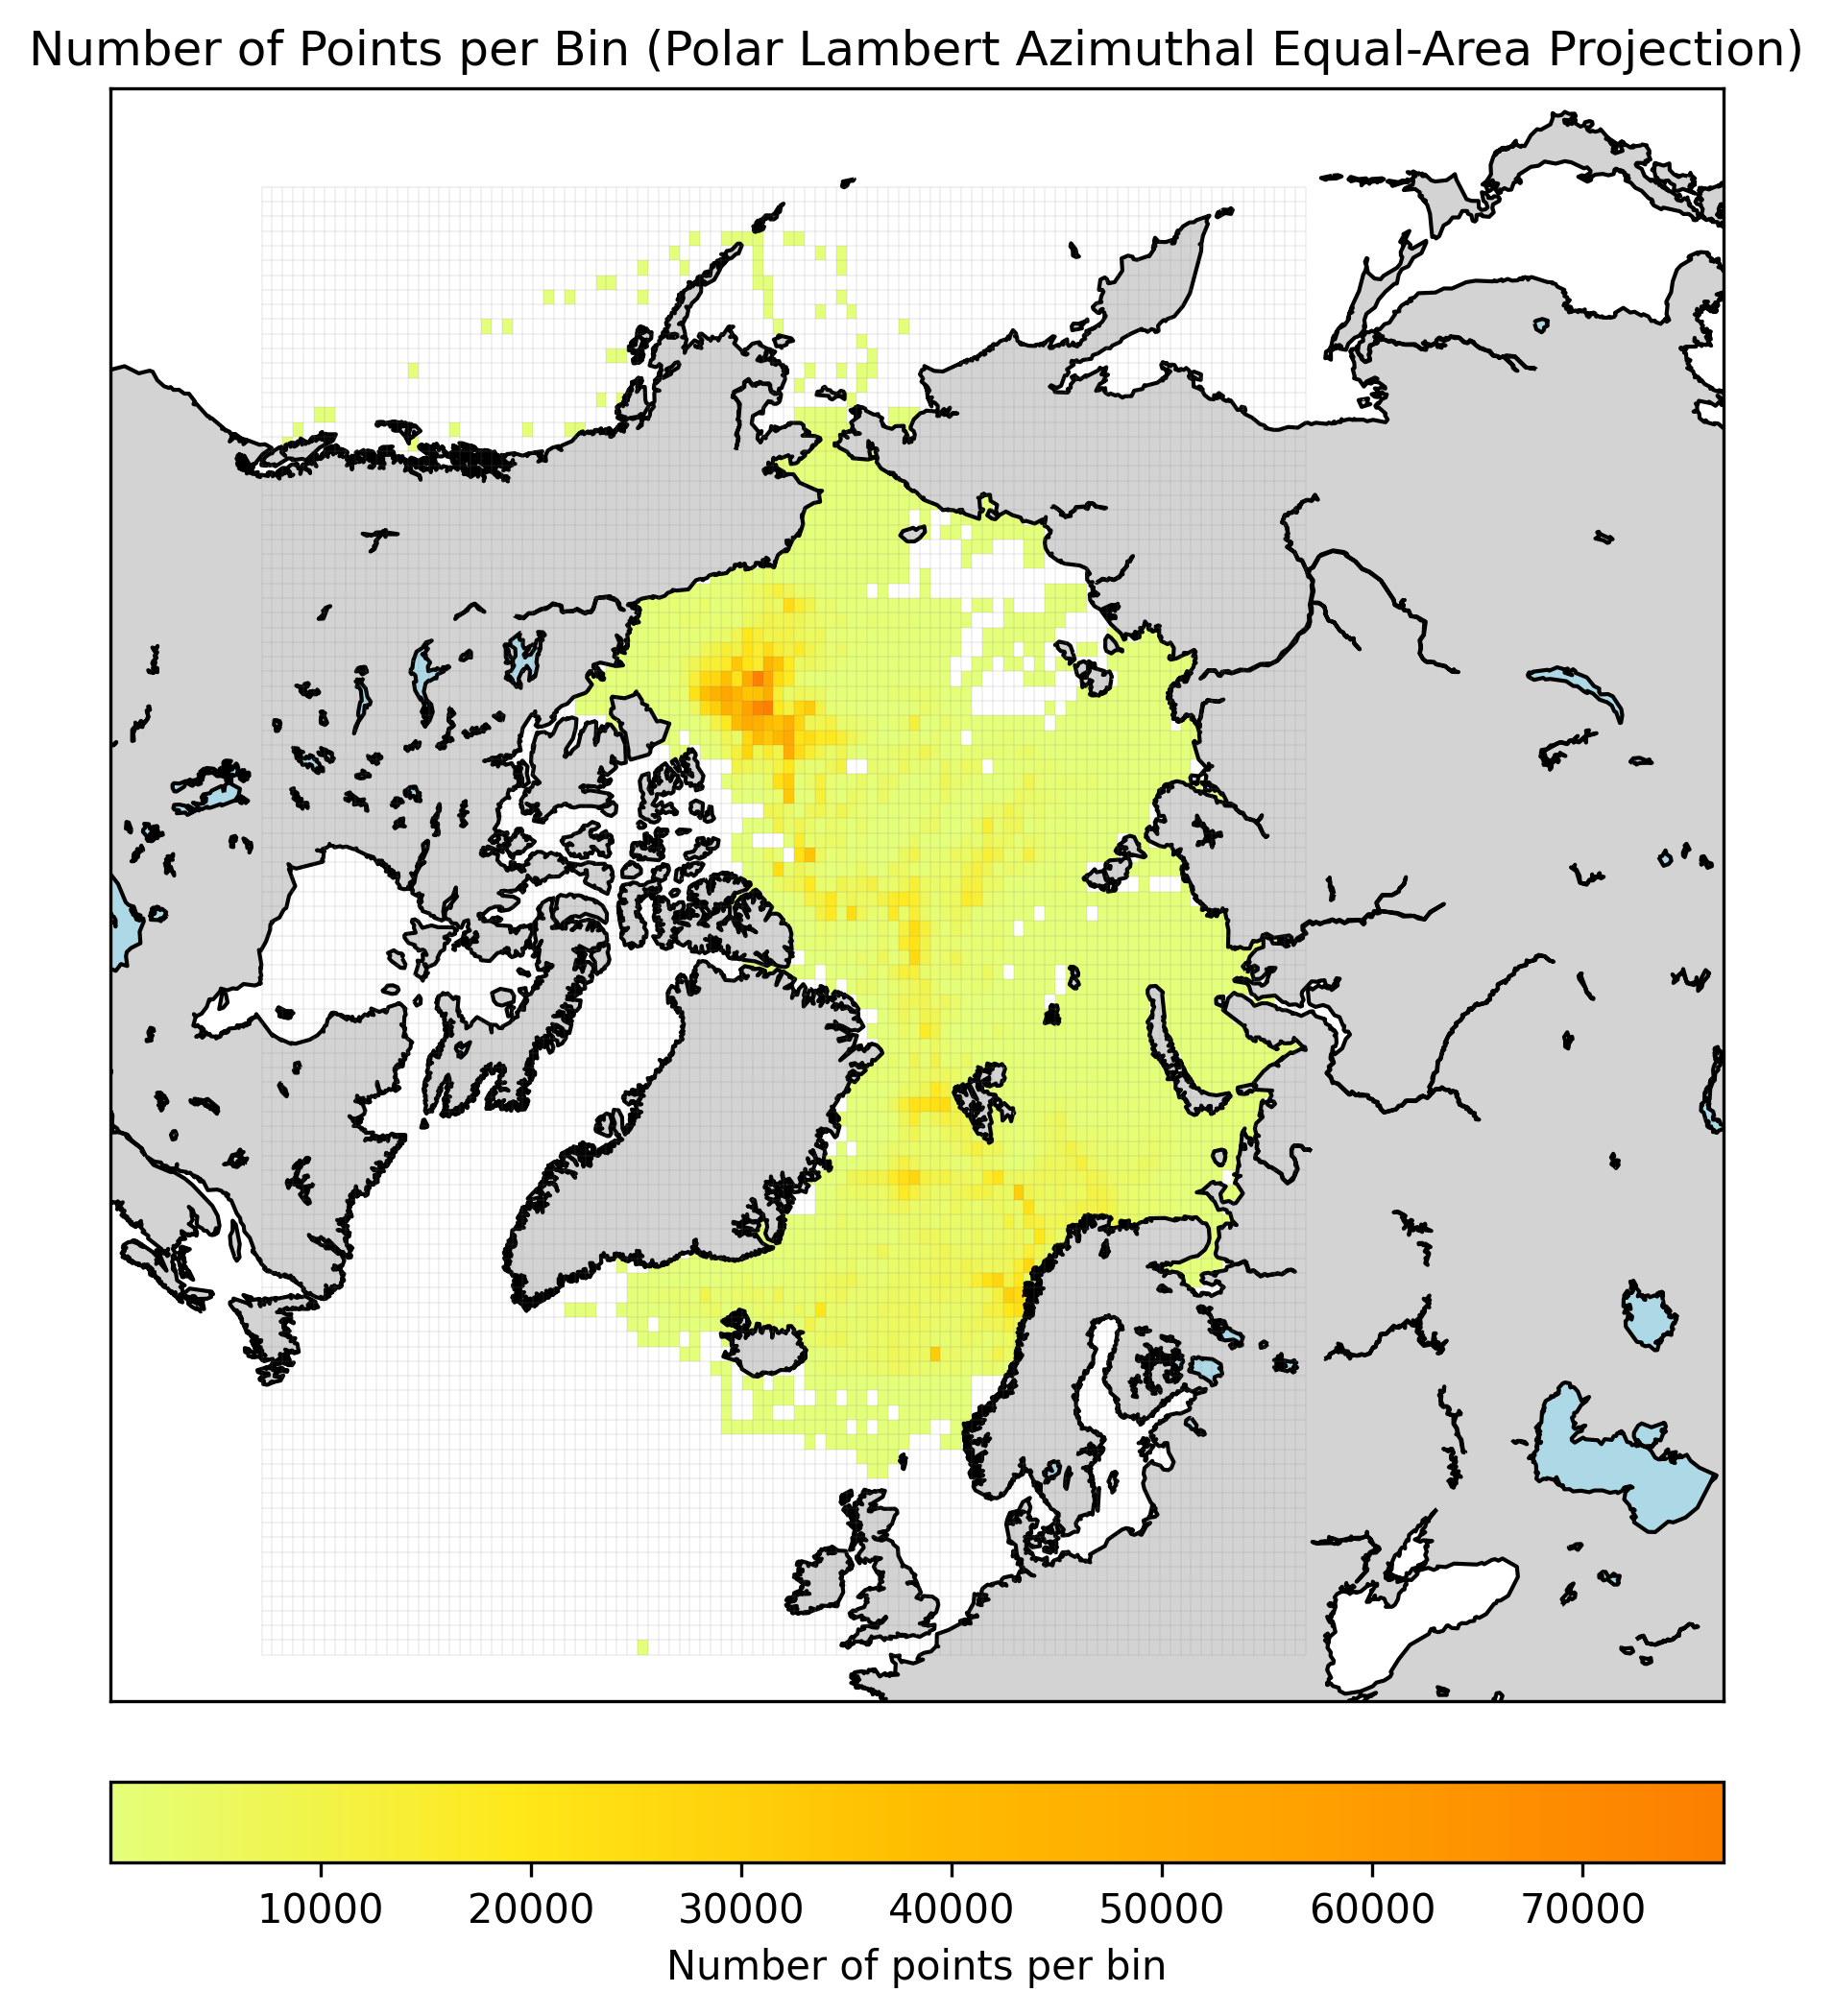

In [23]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='nplaea', projection_name='Polar Lambert Azimuthal Equal-Area')

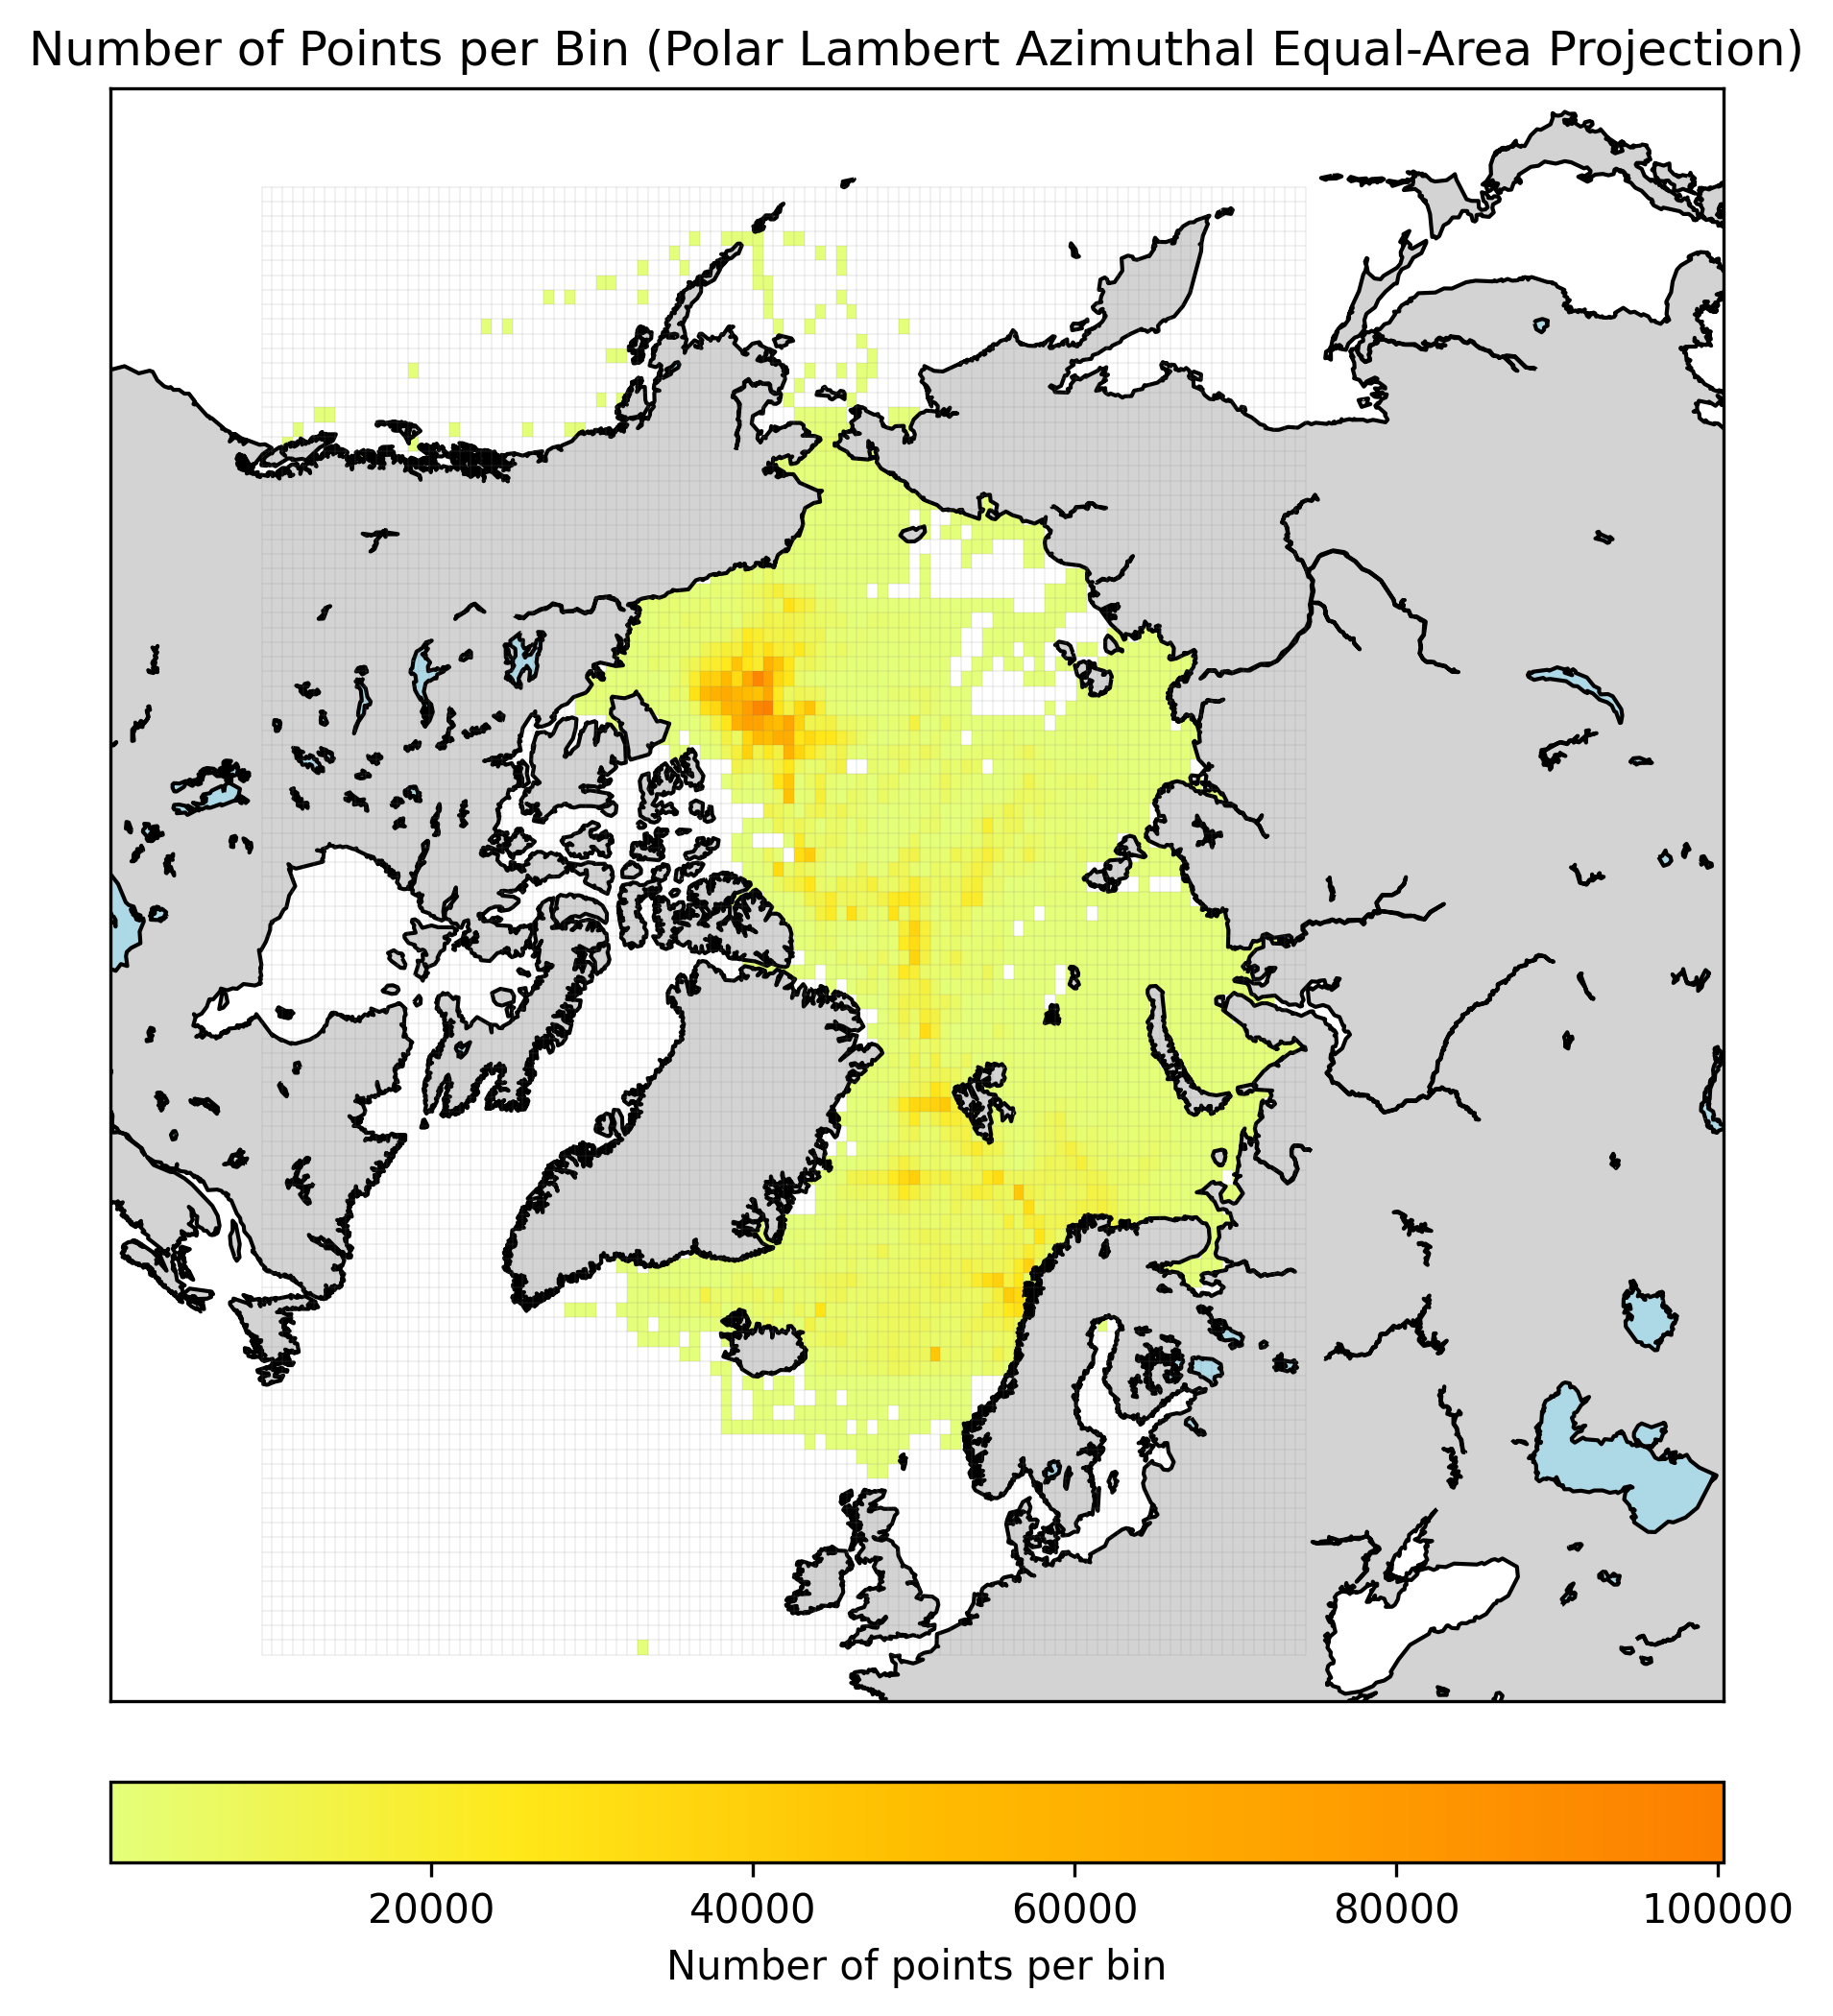

In [24]:
plot_heatmap_npts_xy(df_ST, n_x_bins=100, n_y_bins=100, projection='nplaea', projection_name='Polar Lambert Azimuthal Equal-Area')

(array([ 56843.,  64034.,  81665.,  80490., 127668.,  96433.,  70830.,
        104914.,  91155., 121032.,  80359.,  77430.,  58323.,  92617.,
         95310.,  81233.,  82286., 106570.,  93346.,  89196.,  71241.,
         89982., 104801.,  97351., 107522., 182594., 409815., 610865.,
        690514., 426606., 371294., 308837., 318433., 380576., 390584.,
        315077.,  78843.,  89368., 104999., 254896., 135012., 208915.,
        335049.]),
 array([1980., 1981., 1982., 1983., 1984., 1985., 1986., 1987., 1988.,
        1989., 1990., 1991., 1992., 1993., 1994., 1995., 1996., 1997.,
        1998., 1999., 2000., 2001., 2002., 2003., 2004., 2005., 2006.,
        2007., 2008., 2009., 2010., 2011., 2012., 2013., 2014., 2015.,
        2016., 2017., 2018., 2019., 2020., 2021., 2022., 2023.]),
 <BarContainer object of 43 artists>)

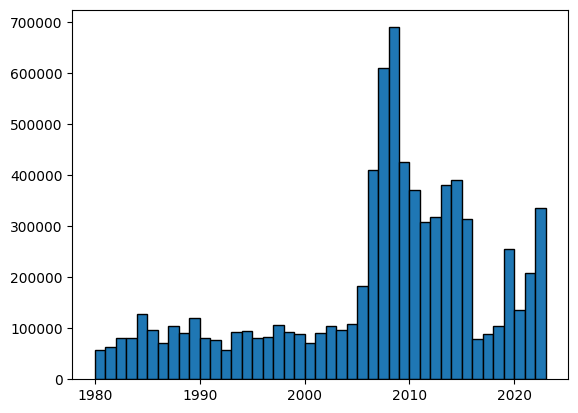

In [25]:
plt.hist(df_sampled['year'], bins=range(df_sampled['year'].min(), df_sampled['year'].max() + 1), edgecolor='black')